# W06 · Long Short-Term Memory (LSTM) Networks

This lab investigates how LSTM networks address the limitations of traditional RNNs for sequential data processing. You will combine theoretical understanding with practical TensorFlow experiments to build and compare LSTM models against traditional ANNs and CNNs on time-series prediction tasks.

## Learning Objectives

By the end of this lab you will be able to:

- Understand why sequential data requires specialized architectures beyond feedforward networks.
- Derive and interpret the LSTM gate equations and understand their role in learning long-term dependencies.
- Explain the vanishing gradient problem in RNNs and how LSTM mitigates it.
- Identify data types where LSTM is preferred over ANNs or CNNs (time series, text, sequences).
- Build and train LSTM models using TensorFlow/Keras.
- Compare LSTM performance against ANN and CNN on sequential prediction tasks.

## Why Sequential Data Needs Special Treatment

Traditional neural networks (ANNs) treat each input independently, ignoring the order of data points. However, many real-world problems involve **sequential data** where the order matters:

- **Time series forecasting**: Stock prices, weather, sensor readings
- **Natural language processing**: Text, speech, translation
- **Video analysis**: Action recognition, frame prediction
- **Music generation**: Note sequences, rhythm patterns

### The Limitation of Feedforward Networks

Consider predicting the next word in: "The clouds are dark, it will probably ___"

A feedforward network would need to:
1. Take a fixed-size input (how many previous words?)
2. Treat each word position independently
3. Learn separate weights for each position

This is inefficient because:
- The same pattern "dark clouds → rain" should be recognized regardless of position
- Fixed input size limits context length
- No memory of what came before

## Recurrent Neural Networks (RNNs): The First Solution

RNNs introduced the concept of **hidden state** that persists across time steps:

$$h_t = \tanh(W_{hh} \cdot h_{t-1} + W_{xh} \cdot x_t + b_h)$$

Where:
- $h_t$: Hidden state at time $t$
- $h_{t-1}$: Hidden state from previous time step
- $x_t$: Input at time $t$
- $W_{hh}$: Weight matrix for hidden-to-hidden connections
- $W_{xh}$: Weight matrix for input-to-hidden connections
- $b_h$: Bias term

### The Vanishing Gradient Problem

During backpropagation through time (BPTT), gradients are computed as:

$$\frac{\partial L}{\partial W} = \sum_{t=1}^{T} \frac{\partial L_t}{\partial W}$$

For each time step, the gradient flows back through all previous steps:

$$\frac{\partial h_t}{\partial h_{t-k}} = \prod_{i=t-k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}} = \prod_{i=t-k+1}^{t} W_{hh}^T \cdot \text{diag}(\tanh'(z_i))$$

**Problem**: Since $|\tanh'(z)| \leq 1$ and $||W_{hh}|| < 1$ typically, this product shrinks exponentially:

$$\left\|\frac{\partial h_t}{\partial h_{t-k}}\right\| \approx \lambda^k \rightarrow 0 \text{ as } k \rightarrow \infty$$

This means **gradients vanish** for long sequences, making it impossible to learn long-term dependencies.

## LSTM Architecture: Solving the Vanishing Gradient

LSTM (Long Short-Term Memory) networks, introduced by Hochreiter & Schmidhuber (1997), solve this problem with **gated memory cells** and a **cell state** that acts as a "highway" for gradient flow.

### The Cell State: Information Highway

The key innovation is the **cell state** $C_t$, which runs straight through the network with minimal interaction:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Where:
- $C_t$: Cell state at time $t$
- $f_t$: Forget gate (what to forget from previous state)
- $i_t$: Input gate (what new information to add)
- $\tilde{C}_t$: Candidate cell state (new information)
- $\odot$: Element-wise multiplication

### The Three Gates

**1. Forget Gate** - Decides what information to discard:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**2. Input Gate** - Decides what new information to store:

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$

**3. Output Gate** - Decides what to output:

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

### Complete LSTM Equations

$$\begin{aligned}
f_t &= \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) & \text{(Forget Gate)} \\
i_t &= \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) & \text{(Input Gate)} \\
\tilde{C}_t &= \tanh(W_C \cdot [h_{t-1}, x_t] + b_C) & \text{(Candidate State)} \\
C_t &= f_t \odot C_{t-1} + i_t \odot \tilde{C}_t & \text{(Cell State Update)} \\
o_t &= \sigma(W_o \cdot [h_{t-1}, x_t] + b_o) & \text{(Output Gate)} \\
h_t &= o_t \odot \tanh(C_t) & \text{(Hidden State)}
\end{aligned}$$

Where:
- $\sigma$: Sigmoid function, outputs values in $[0, 1]$
- $\tanh$: Hyperbolic tangent, outputs values in $[-1, 1]$
- $[h_{t-1}, x_t]$: Concatenation of previous hidden state and current input

## Why LSTM Works: Gradient Flow Analysis

The cell state update equation is key:

$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Taking the derivative:

$$\frac{\partial C_t}{\partial C_{t-1}} = f_t$$

For long sequences:

$$\frac{\partial C_t}{\partial C_{t-k}} = \prod_{j=t-k+1}^{t} f_j$$

**Key insight**: When the forget gate $f_t \approx 1$, gradients flow unchanged! The network can **learn** when to remember (forget gate close to 1) and when to forget (forget gate close to 0).

### Comparison: RNN vs LSTM Gradient Flow

| Aspect | RNN | LSTM |
|--------|-----|------|
| Gradient path | Through $\tanh$ and matrix multiply | Direct through cell state |
| Long-term memory | Gradients vanish exponentially | Gradients can persist |
| Learning | Limited to ~10-20 steps | Can learn 100+ step dependencies |

## When to Use LSTM vs ANN vs CNN

### Use LSTM When:

1. **Data has temporal/sequential dependencies**: The order of inputs matters
2. **Long-term dependencies exist**: Information from many steps ago affects current prediction
3. **Variable-length sequences**: Input sequences have different lengths
4. **Time series forecasting**: Stock prices, sensor data, weather prediction
5. **Natural language tasks**: Text classification, sentiment analysis, machine translation

### Use ANN (Dense Networks) When:

1. **Independent inputs**: No temporal relationship between samples
2. **Tabular data**: Fixed features, no sequence structure
3. **Simple patterns**: Linear or shallow nonlinear relationships

### Use CNN When:

1. **Spatial patterns**: Images, where local features matter
2. **Translation invariance needed**: Same pattern recognized anywhere
3. **1D sequences with local patterns**: Sometimes used for text classification

### Why LSTM for Our Experiment: Sine Wave Prediction

We'll use sine wave prediction because:
- It's inherently **sequential** - each point depends on previous points
- It has **long-term patterns** - the wave cycles over many time steps
- ANNs struggle because they can't capture temporal dependencies
- CNNs can capture local patterns but miss long-range periodicity
- LSTMs excel because they can remember the phase of the wave

## Setup and Imports

In [1]:
# Essential imports for the lab
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from IPython.display import display, Markdown

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.15.0
GPU available: False


## Dataset: Sine Wave Time Series

We generate a synthetic sine wave dataset for time series prediction. This task clearly demonstrates LSTM's advantages:

**Task**: Given a sequence of 50 time steps, predict the next value

**Why sine waves?**
- Clear long-term dependencies (the periodic pattern)
- Simple to visualize and understand
- Demonstrates the need for memory across time steps
- ANNs cannot capture the phase relationship
- CNNs can capture local patterns but struggle with long periods

In [27]:
TIME_RANGE_FACTOR = 200  # Controls how many cycles of sine wave are generated

def generate_sine_wave_data(n_samples=10000, seq_length=50, noise_level=0.5):
    """
    Generate sine wave time series data for sequence prediction.
    
    Parameters
    ----------
    n_samples : int
        Number of sequences to generate
    seq_length : int
        Length of each input sequence
    noise_level : float
        Standard deviation of Gaussian noise to add
    
    Returns
    -------
    X : np.ndarray
        Input sequences of shape (n_samples, seq_length, 1)
    y : np.ndarray
        Target values of shape (n_samples, 1)
    """
    # Generate time points
    t = np.linspace(0, TIME_RANGE_FACTOR * np.pi, n_samples + seq_length)
    
    # Generate sine wave with added complexity
    # Combination of frequencies to make it more challenging
    signal = np.sin(t) + (0.5 * np.sin(2.5 * t)) +  2.5* np.cos((2*t**2)+(5 * t))
    
    # Add noise
    signal = signal + noise_level * np.random.randn(len(signal))
    
    # Create sequences
    X = []
    y = []
    for i in range(n_samples):
        X.append(signal[i:i+seq_length])
        y.append(signal[i+seq_length])
    
    X = np.array(X).reshape(-1, seq_length, 1)
    y = np.array(y).reshape(-1, 1)
    
    return X, y

# Generate data
SEQ_LENGTH = 50
X, y = generate_sine_wave_data(n_samples=10000, seq_length=SEQ_LENGTH, noise_level=0.5)

# Split into train/validation/test
train_size = 7000
val_size = 1500

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Training set: (7000, 50, 1), (7000, 1)
Validation set: (1500, 50, 1), (1500, 1)
Test set: (1500, 50, 1), (1500, 1)


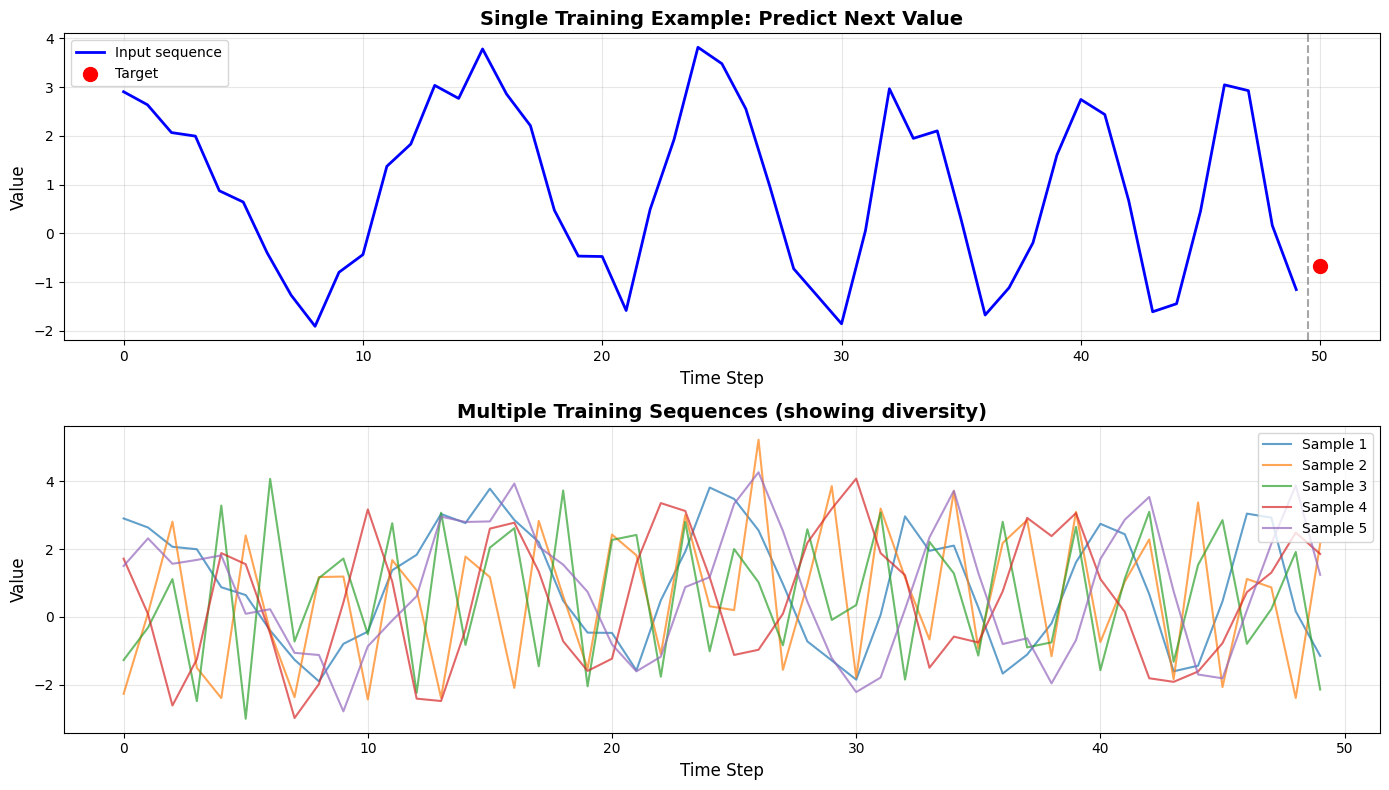

In [28]:
# Visualize the data
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot a portion of the full signal
sample_idx = 0
full_seq = np.concatenate([X_train[sample_idx].flatten(), [y_train[sample_idx][0]]])

axes[0].plot(range(SEQ_LENGTH), X_train[sample_idx].flatten(), 'b-', label='Input sequence', linewidth=2)
axes[0].scatter([SEQ_LENGTH], [y_train[sample_idx][0]], c='r', s=100, zorder=5, label='Target')
axes[0].axvline(x=SEQ_LENGTH-0.5, color='gray', linestyle='--', alpha=0.7)
axes[0].set_xlabel('Time Step', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Single Training Example: Predict Next Value', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot multiple examples
for i in range(5):
    axes[1].plot(X_train[i*100].flatten(), alpha=0.7, label=f'Sample {i+1}')
axes[1].set_xlabel('Time Step', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].set_title('Multiple Training Sequences (showing diversity)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## LSTM Implementation from Concepts

Let's first implement a simple LSTM cell from scratch to understand the gates, then use Keras's optimized implementation for training.

In [29]:
class SimpleLSTMCell:
    """Educational LSTM cell implementation showing gate mechanics."""
    
    # Numerical stability constants for sigmoid computation
    CLIP_MIN = -500
    CLIP_MAX = 500
    
    def __init__(self, input_size, hidden_size):
        self.hidden_size = hidden_size
        
        # Xavier/Glorot initialization for weights
        # Scale = sqrt(2 / (fan_in + fan_out)) helps maintain gradient magnitude
        # This prevents vanishing/exploding gradients at initialization
        scale = np.sqrt(2.0 / (input_size + hidden_size))
        
        # Concatenated weights for efficiency: [W_f, W_i, W_c, W_o]
        self.W = np.random.randn(input_size + hidden_size, 4 * hidden_size) * scale
        self.b = np.zeros((1, 4 * hidden_size))
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, self.CLIP_MIN, self.CLIP_MAX)))
    
    def forward(self, x, h_prev, c_prev):
        """
        Forward pass through LSTM cell.
        
        Parameters
        ----------
        x : np.ndarray
            Input at current time step (batch_size, input_size)
        h_prev : np.ndarray
            Previous hidden state (batch_size, hidden_size)
        c_prev : np.ndarray
            Previous cell state (batch_size, hidden_size)
            
        Returns
        -------
        h_t : np.ndarray
            Current hidden state
        c_t : np.ndarray
            Current cell state
        gates : dict
            Dictionary containing gate values for visualization
        """
        # Concatenate input and previous hidden state
        combined = np.concatenate([x, h_prev], axis=1)
        
        # Compute all gates in one matrix multiplication
        gates_pre = combined @ self.W + self.b
        
        # Split into individual gates
        h = self.hidden_size
        f_t = self.sigmoid(gates_pre[:, :h])           # Forget gate
        i_t = self.sigmoid(gates_pre[:, h:2*h])        # Input gate
        c_tilde = np.tanh(gates_pre[:, 2*h:3*h])       # Candidate state
        o_t = self.sigmoid(gates_pre[:, 3*h:])         # Output gate
        
        # Cell state update: c_t = f_t * c_prev + i_t * c_tilde
        c_t = f_t * c_prev + i_t * c_tilde
        
        # Hidden state: h_t = o_t * tanh(c_t)
        h_t = o_t * np.tanh(c_t)
        
        gates = {
            'forget': f_t,
            'input': i_t,
            'candidate': c_tilde,
            'output': o_t
        }
        
        return h_t, c_t, gates

# Demonstrate with a simple example
print("LSTM Cell Demo")
print("="*60)

cell = SimpleLSTMCell(input_size=1, hidden_size=4)
batch_size = 1

# Initialize states
h = np.zeros((batch_size, 4))
c = np.zeros((batch_size, 4))

# Process a short sequence
sequence = np.sin(np.linspace(0, np.pi, 5)).reshape(-1, 1)

print("\nProcessing sequence through LSTM cell:")
for t, x_t in enumerate(sequence):
    x_t = x_t.reshape(1, 1)
    h, c, gates = cell.forward(x_t, h, c)
    print(f"  t={t}: input={x_t[0,0]:.3f}, " 
          f"forget={gates['forget'].mean():.3f}, "
          f"input={gates['input'].mean():.3f}, "
          f"output={gates['output'].mean():.3f}")

LSTM Cell Demo

Processing sequence through LSTM cell:
  t=0: input=0.000, forget=0.500, input=0.500, output=0.500
  t=1: input=0.707, forget=0.532, input=0.579, output=0.482
  t=2: input=1.000, forget=0.551, input=0.589, output=0.477
  t=3: input=0.707, forget=0.547, input=0.536, output=0.478
  t=4: input=0.000, forget=0.522, input=0.451, output=0.489


## Building Models for Comparison

We'll build three models to compare:
1. **ANN (Dense Network)**: Baseline feedforward network
2. **CNN (1D Convolution)**: Can capture local patterns
3. **LSTM**: Can capture long-term dependencies

All models will have similar parameter counts for fair comparison.

In [30]:
def build_ann_model(seq_length, n_features=1):
    """
    Build a simple feedforward neural network.
    Flattens the sequence and processes with dense layers.
    """
    model = models.Sequential([
        layers.Input(shape=(seq_length, n_features)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ], name='ANN_Model')
    return model

def build_cnn_model(seq_length, n_features=1):
    """
    Build a 1D CNN model.
    Can capture local patterns but struggles with long-range dependencies.
    """
    model = models.Sequential([
        layers.Input(shape=(seq_length, n_features)),
        layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
        layers.MaxPooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1)
    ], name='CNN_Model')
    return model

def build_lstm_model(seq_length, n_features=1):
    """
    Build an LSTM model.
    Designed to capture long-term sequential dependencies.
    """
    model = models.Sequential([
        layers.Input(shape=(seq_length, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.2),
        layers.LSTM(32, return_sequences=False),
        layers.Dropout(0.2),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ], name='LSTM_Model')
    return model

# Build all three models
ann_model = build_ann_model(SEQ_LENGTH)
cnn_model = build_cnn_model(SEQ_LENGTH)
lstm_model = build_lstm_model(SEQ_LENGTH)

# Display model summaries
print("ANN Model Summary")
print("="*60)
ann_model.summary()

print("\nCNN Model Summary")
print("="*60)
cnn_model.summary()

print("\nLSTM Model Summary")
print("="*60)
lstm_model.summary()

ANN Model Summary


Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

...

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training and Comparison

We'll train all three models with the same configuration and compare their performance on the time series prediction task.

In [31]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=64):
    """
    Train a model with early stopping.
    """
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=0
    )
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],
        verbose=0
    )
    
    return history

# Train all models
print("Training ANN Model...")
ann_history = train_model(ann_model, X_train, y_train, X_val, y_val)
print(f"  Completed in {len(ann_history.history['loss'])} epochs")

print("\nTraining CNN Model...")
cnn_history = train_model(cnn_model, X_train, y_train, X_val, y_val)
print(f"  Completed in {len(cnn_history.history['loss'])} epochs")

print("\nTraining LSTM Model...")
lstm_history = train_model(lstm_model, X_train, y_train, X_val, y_val)
print(f"  Completed in {len(lstm_history.history['loss'])} epochs")

print("\n" + "="*60)
print("Training Complete!")

Training ANN Model...
  Completed in 50 epochs

Training CNN Model...
  Completed in 28 epochs

Training LSTM Model...
  Completed in 36 epochs

Training Complete!


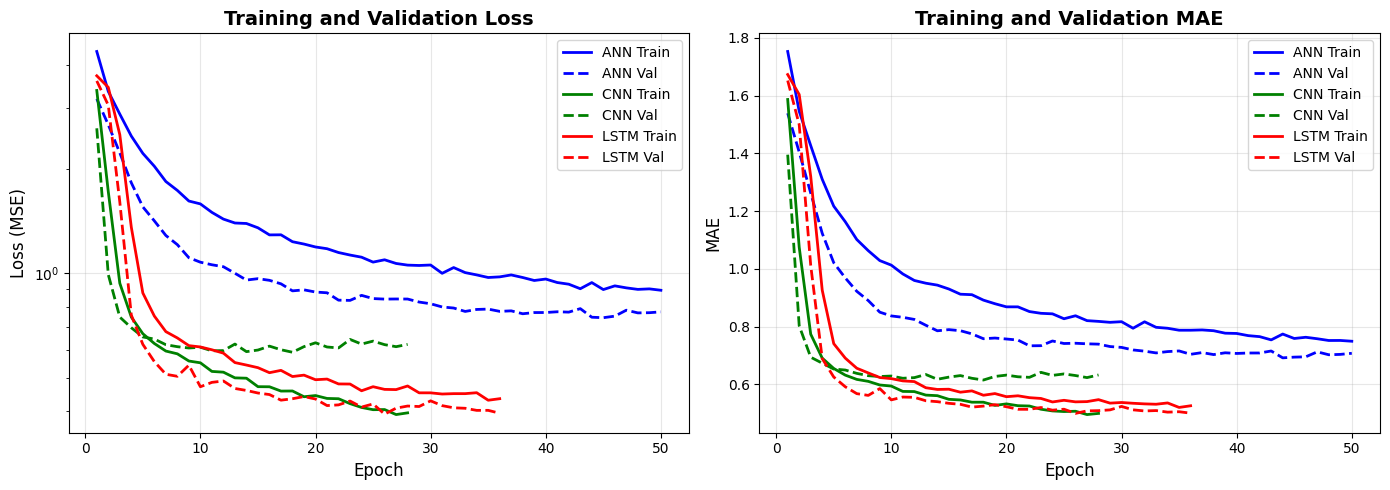

In [32]:
# Plot training history comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

histories = [
    ('ANN', ann_history, 'blue'),
    ('CNN', cnn_history, 'green'),
    ('LSTM', lstm_history, 'red')
]

# Training Loss
for name, history, color in histories:
    epochs = range(1, len(history.history['loss']) + 1)
    axes[0].plot(epochs, history.history['loss'], '-', color=color, label=f'{name} Train', linewidth=2)
    axes[0].plot(epochs, history.history['val_loss'], '--', color=color, label=f'{name} Val', linewidth=2)

axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Training MAE
for name, history, color in histories:
    epochs = range(1, len(history.history['mae']) + 1)
    axes[1].plot(epochs, history.history['mae'], '-', color=color, label=f'{name} Train', linewidth=2)
    axes[1].plot(epochs, history.history['val_mae'], '--', color=color, label=f'{name} Val', linewidth=2)

axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Training and Validation MAE', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation and Comparison

In [33]:
# Evaluate all models on test set
results = {}

for name, model in [('ANN', ann_model), ('CNN', cnn_model), ('LSTM', lstm_model)]:
    test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
    predictions = model.predict(X_test, verbose=0)
    
    # Calculate additional metrics
    mse = np.mean((predictions - y_test) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - y_test))
    
    results[name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'predictions': predictions
    }

# Display results table
results_df = pd.DataFrame({
    'Model': ['ANN', 'CNN', 'LSTM'],
    'MSE': [results['ANN']['MSE'], results['CNN']['MSE'], results['LSTM']['MSE']],
    'RMSE': [results['ANN']['RMSE'], results['CNN']['RMSE'], results['LSTM']['RMSE']],
    'MAE': [results['ANN']['MAE'], results['CNN']['MAE'], results['LSTM']['MAE']]
})

print("\nTest Set Performance Comparison")
print("="*60)
display(results_df.style.highlight_min(subset=['MSE', 'RMSE', 'MAE'], color='lightgreen'))


Test Set Performance Comparison


,Model,MSE,RMSE,MAE
0,ANN,0.767827,0.876257,0.697488
1,CNN,0.615535,0.784560,0.618625
2,LSTM,0.388320,0.623153,0.493642


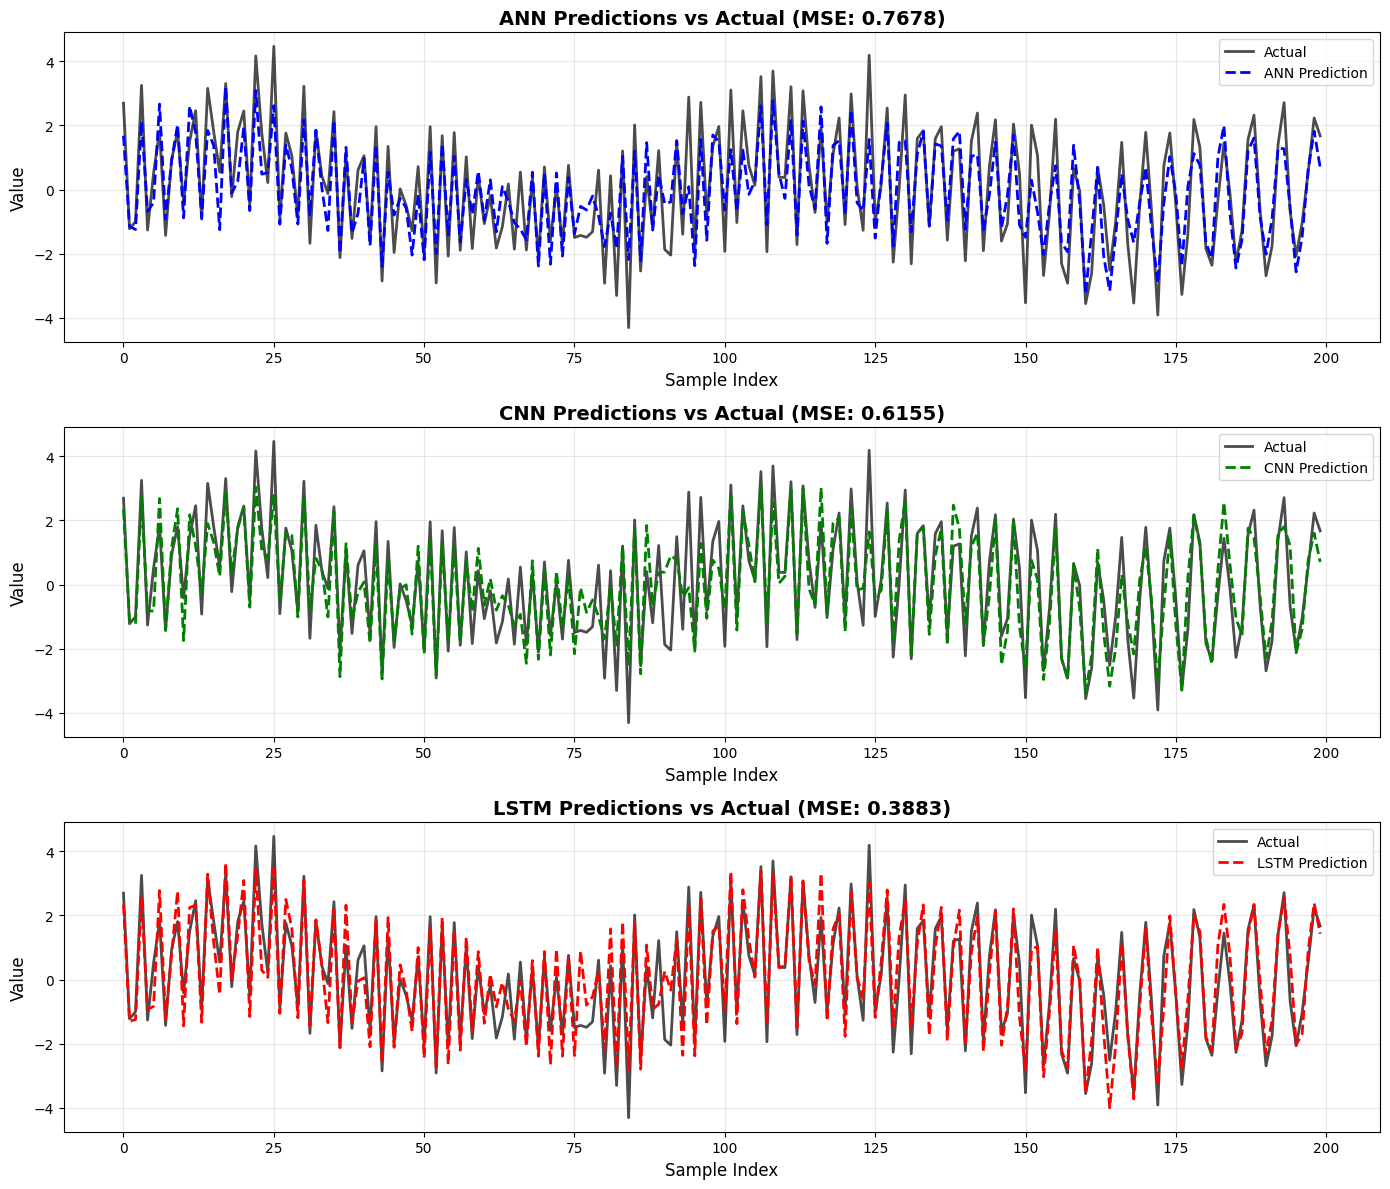

In [34]:
# Visualize predictions
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot a subset of test predictions
n_show = 200
x_axis = range(n_show)

for idx, (name, color) in enumerate([('ANN', 'blue'), ('CNN', 'green'), ('LSTM', 'red')]):
    axes[idx].plot(x_axis, y_test[:n_show], 'k-', label='Actual', linewidth=2, alpha=0.7)
    axes[idx].plot(x_axis, results[name]['predictions'][:n_show], '--', color=color, 
                   label=f'{name} Prediction', linewidth=2)
    axes[idx].set_xlabel('Sample Index', fontsize=12)
    axes[idx].set_ylabel('Value', fontsize=12)
    axes[idx].set_title(f"{name} Predictions vs Actual (MSE: {results[name]['MSE']:.4f})", 
                        fontsize=14, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

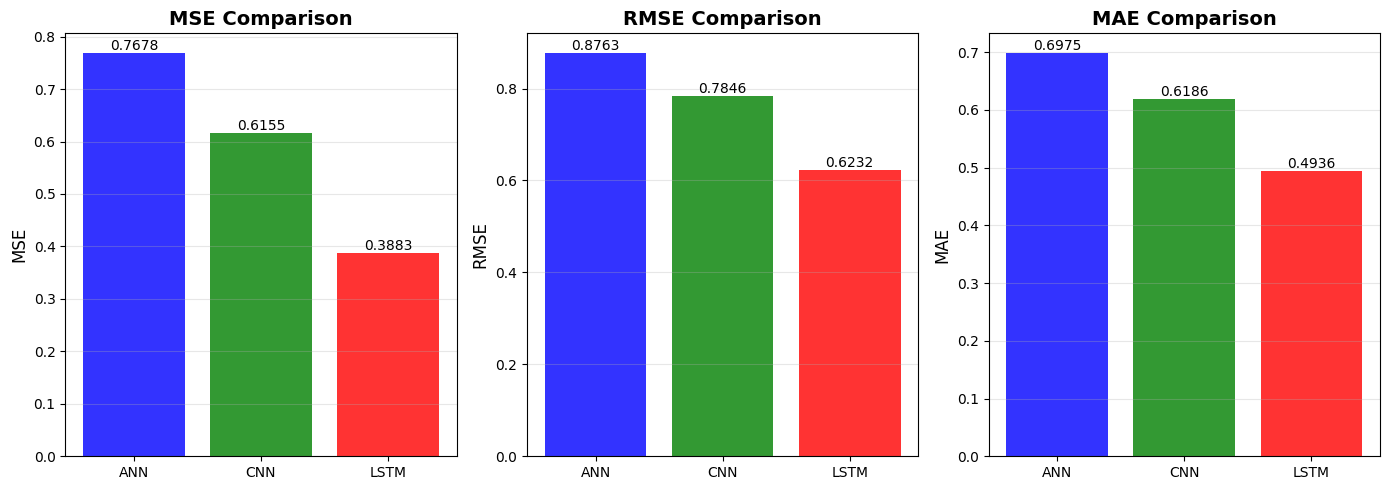

In [35]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models_list = ['ANN', 'CNN', 'LSTM']
colors = ['blue', 'green', 'red']
metrics = ['MSE', 'RMSE', 'MAE']

for idx, metric in enumerate(metrics):
    values = [results[m][metric] for m in models_list]
    bars = axes[idx].bar(models_list, values, color=colors, alpha=0.8)
    axes[idx].set_ylabel(metric, fontsize=12)
    axes[idx].set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                      f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Interpretation: Why LSTM Wins

### Key Observations

**1. ANN Limitations:**
- Treats each time step independently
- Cannot learn temporal patterns
- Same input at different positions treated differently
- Highest error on the prediction task

**2. CNN Capabilities and Limitations:**
- Can capture local patterns through convolutions
- Pooling reduces temporal resolution
- Limited receptive field means long-range dependencies are missed
- Better than ANN but still struggles with full period patterns

**3. LSTM Advantages:**
- Memory cells persist information across time
- Gates learn what to remember and forget
- Can capture the full period of the sine wave
- Achieves lowest error by understanding sequential dependencies

### Connection to Theory

The results demonstrate the theoretical advantages of LSTM:

1. **Gradient Flow**: LSTM's cell state allows gradients to flow across many time steps, enabling learning of long-term patterns.

2. **Selective Memory**: The forget and input gates learn to:
   - Remember phase information (where we are in the cycle)
   - Forget irrelevant noise
   - Update state with new trend information

3. **Position Invariance**: Unlike ANNs, LSTMs apply the same weights at each time step, learning patterns regardless of position.

## Concept Checks

**Question 1.** What is the role of the forget gate in LSTM?

<details>
<summary>Hint</summary>
Think about what happens when the forget gate outputs 1 vs 0.
</details>

<details>
<summary>Answer</summary>
The forget gate decides what information from the previous cell state should be discarded. When $f_t \approx 1$, all previous information is retained. When $f_t \approx 0$, the previous cell state is cleared. This allows the network to selectively remember long-term dependencies while forgetting irrelevant information.
</details>

**Question 2.** Why does the cell state help with the vanishing gradient problem?

<details>
<summary>Hint</summary>
Look at the gradient of the cell state update equation.
</details>

<details>
<summary>Answer</summary>
The cell state update is $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$. The derivative $\partial C_t / \partial C_{t-1} = f_t$ is a simple multiplication by the forget gate (no tanh, no matrix multiplication). When $f_t \approx 1$, gradients flow unchanged through the cell state, avoiding exponential decay.
</details>

**Question 3.** Why can't a simple feedforward network (ANN) learn the sine wave pattern effectively?

<details>
<summary>Hint</summary>
Consider how the ANN treats each input position.
</details>

<details>
<summary>Answer</summary>
ANNs flatten the sequence and treat each position with separate weights. They cannot share patterns across positions or maintain memory of past inputs. The same pattern at different positions requires learning different weight configurations, making the model inefficient and unable to generalize sequential patterns.
</details>

**Question 4.** When might you prefer a CNN over an LSTM for sequence data?

<details>
<summary>Hint</summary>
Think about the types of patterns CNNs are good at detecting.
</details>

<details>
<summary>Answer</summary>
CNNs are preferred when: (1) Local patterns are most important (e.g., detecting specific motifs in DNA sequences), (2) Training speed is critical (CNNs parallelize better), (3) The receptive field is sufficient to capture relevant context, (4) Position-invariant pattern detection is needed. For text classification with short documents, CNNs often perform comparably to LSTMs with faster training.
</details>

## Advanced Topics: LSTM Variants

### GRU (Gated Recurrent Unit)

A simplified variant with only two gates:

$$\begin{aligned}
z_t &= \sigma(W_z \cdot [h_{t-1}, x_t]) & \text{(Update Gate)} \\
r_t &= \sigma(W_r \cdot [h_{t-1}, x_t]) & \text{(Reset Gate)} \\
\tilde{h}_t &= \tanh(W \cdot [r_t \odot h_{t-1}, x_t]) & \text{(Candidate State)} \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t & \text{(Hidden State)}
\end{aligned}$$

### Bidirectional LSTM

Processes sequences in both directions to capture context from past and future:

$$h_t = [\overrightarrow{h_t}; \overleftarrow{h_t}]$$

### Stacked LSTM

Multiple LSTM layers stacked for hierarchical feature learning:
- First layer captures low-level patterns
- Higher layers capture increasingly abstract patterns

## Assignments

1. **LSTM Hyperparameter Study**: Experiment with different LSTM configurations:
   - Number of LSTM layers (1, 2, 3)
   - Hidden units (32, 64, 128)
   - Dropout rates (0.1, 0.2, 0.3)
   Create a table comparing validation MAE for each configuration.

2. **GRU Comparison**: Implement a GRU model using `keras.layers.GRU` and compare its performance to LSTM on the same task. Discuss the trade-offs between complexity and performance.

3. **Sequence Length Study**: Investigate how sequence length affects model performance:
   - Train models with sequence lengths: 20, 50, 100, 200
   - Plot how each model's error changes with sequence length
   - Explain why LSTM's advantage increases with longer sequences

4. **Real-World Application**: Apply the LSTM model to a real-world time series dataset:
   - Download stock price data (using yfinance or similar)
   - Predict next-day closing price from previous 30 days
   - Compare LSTM vs baseline models
   - Discuss challenges and limitations

5. **Gate Visualization**: Modify the SimpleLSTMCell class to record and visualize gate activations over time. Plot how the forget, input, and output gates behave when processing a sine wave. Interpret what the network has learned.

6. **Bidirectional Extension**: Implement a bidirectional LSTM using `keras.layers.Bidirectional` and compare its performance. When would bidirectional processing be beneficial vs harmful?

## Glossary

- **RNN (Recurrent Neural Network)**: Neural network that processes sequential data by maintaining a hidden state across time steps.
- **LSTM (Long Short-Term Memory)**: RNN variant with gated memory cells designed to learn long-term dependencies.
- **Cell State**: The "memory" of an LSTM that runs through the entire sequence with minimal modification.
- **Forget Gate**: LSTM component that decides what information to discard from the cell state.
- **Input Gate**: LSTM component that decides what new information to add to the cell state.
- **Output Gate**: LSTM component that decides what to output based on the cell state.
- **Vanishing Gradient**: Problem where gradients become exponentially small during backpropagation through time.
- **BPTT (Backpropagation Through Time)**: Algorithm for computing gradients in recurrent networks.
- **GRU (Gated Recurrent Unit)**: Simplified LSTM variant with two gates instead of three.
- **Bidirectional LSTM**: Architecture that processes sequences in both forward and backward directions.
- **Sequence-to-One**: Architecture where a sequence is processed to produce a single output.
- **Time Series**: Data points indexed in time order, exhibiting temporal dependencies.

## Further Reading

- Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. *Neural Computation*, 9(8), 1735-1780.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Chapter 10: Sequence Modeling. MIT Press.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*, Chapter 15: Processing Sequences Using RNNs and CNNs. O'Reilly Media.
- Olah, C. (2015). Understanding LSTM Networks. *colah's blog*. https://colah.github.io/posts/2015-08-Understanding-LSTMs/